# Demonstração: rede neural no MNIST

Nesta demonstração, seguimos um fluxo simples e alinhado à Aula 8. O objetivo é treinar uma rede neural convolucional (CNN) no dataset MNIST de dígitos escritos à mão, acompanhar o treino e avaliar o desempenho com métricas e visualizações básicas.

## 1. Importações e configuração
Aqui carregamos as bibliotecas necessárias e fixamos uma semente para reprodutibilidade.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

%matplotlib inline

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

I0000 00:00:1773522967.534879   18422 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2. Carregar o MNIST
O MNIST já vem dividido em treino e teste. Cada imagem tem 28x28 pixels em tons de cinza.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train.shape, x_test.shape

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


((60000, 28, 28), (10000, 28, 28))

## 3. Inspeção rápida
Vamos visualizar algumas imagens para confirmar o formato e o conteúdo.

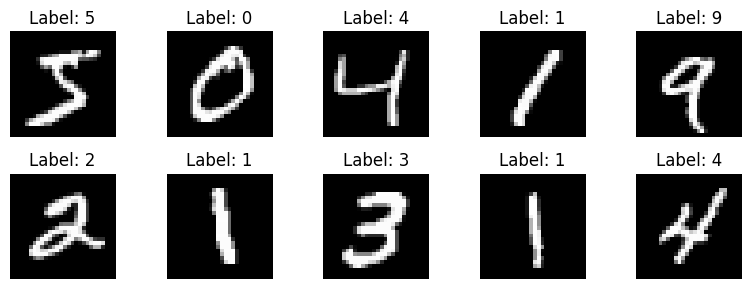

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(8, 3))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Pré-processamento
Normalizamos os pixels para o intervalo [0, 1] e adicionamos o canal de cor (1).

In [4]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

x_train.shape, x_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

## 5. Separar treino e validação
Criamos um conjunto de validação a partir do treino para monitorar overfitting.

In [5]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.15, random_state=SEED, stratify=y_train
)

x_train.shape, x_val.shape

((51000, 28, 28, 1), (9000, 28, 28, 1))

## 6. Definir a arquitetura
Usamos uma CNN simples com camadas convolucionais, pooling e camadas densas.

In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

/media/rodolfo/Cold Files/Projects/Github/unimar/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1773522973.173422   18422 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1773522973.178378   18422 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1773522973.277649   18422 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9362 MB memory:  -> 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Compilar o modelo
Usamos entropia cruzada e o otimizador Adam.

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 8. Treinar o modelo
Monitoramos a validação e usamos early stopping para evitar overfitting.

In [8]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=12,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/12


I0000 00:00:1773522976.274719   18588 service.cc:153] XLA service 0x74e094034190 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773522976.274733   18588 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1773522976.290789   18588 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773522976.397974   18588 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1773522976.428240   18588 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1676__.31


119/399 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6336 - loss: 1.1447

I0000 00:00:1773522979.704541   18588 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


360/399 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7929 - loss: 0.6594

I0000 00:00:1773522980.335856   18587 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1676__.31
I0000 00:00:1773522980.515985   18877 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1773522981.257475   18864 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_4', 8 bytes spill stores, 8 bytes spill loads



399/399 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9121 - loss: 0.2885 - val_accuracy: 0.9754 - val_loss: 0.0825
Epoch 2/12
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9758 - loss: 0.0821 - val_accuracy: 0.9842 - val_loss: 0.0539
Epoch 3/12
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9825 - loss: 0.0579 - val_accuracy: 0.9877 - val_loss: 0.0439
Epoch 4/12
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9865 - loss: 0.0440 - val_accuracy: 0.9883 - val_loss: 0.0427
Epoch 5/12
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9888 - loss: 0.0371 - val_accuracy: 0.9887 - val_loss: 0.0414
Epoch 6/12
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9907 - loss: 0.0306 - val_accuracy: 0.9886 - val_loss: 0.0424
Epoch 7/12
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9916 - loss: 0.0272 - val_accuracy: 0.9896 - val_loss: 0.0386
Epoch 8/12
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9927 - loss: 0.0226 - val_accuracy: 0.9894 - va

## 9. Curvas de treino
Visualizamos perda e acurácia em treino e validação.

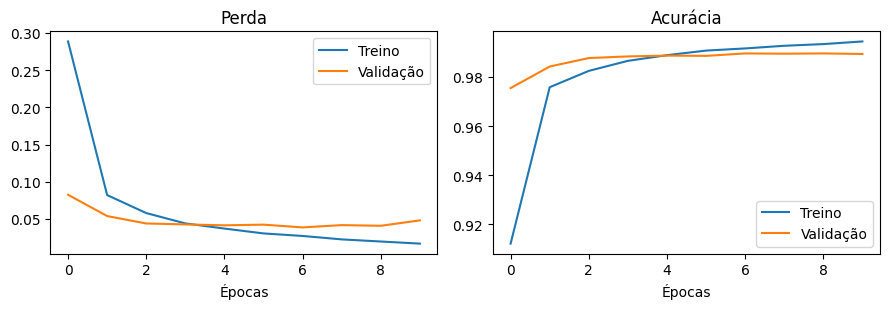

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

axes[0].plot(history.history['loss'], label='Treino')
axes[0].plot(history.history['val_loss'], label='Validação')
axes[0].set_title('Perda')
axes[0].set_xlabel('Épocas')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Treino')
axes[1].plot(history.history['val_accuracy'], label='Validação')
axes[1].set_title('Acurácia')
axes[1].set_xlabel('Épocas')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Avaliar no conjunto de teste
Usamos o conjunto de teste apenas no final para medir desempenho real.

In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Acurácia no teste: {test_acc:.4f}')

Acurácia no teste: 0.9909


## 11. Relatório e matriz de confusão
Agora analisamos as classes mais confundidas.

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



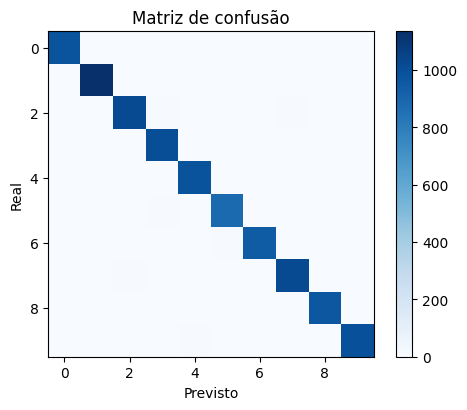

In [11]:
y_proba = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_proba, axis=1)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5.2, 4.2))
plt.imshow(cm, cmap='Blues')
plt.title('Matriz de confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.colorbar()
plt.tight_layout()
plt.show()

## 12. Exemplos de acertos e erros
Visualizamos algumas previsões corretas e incorretas para entender limitações do modelo.

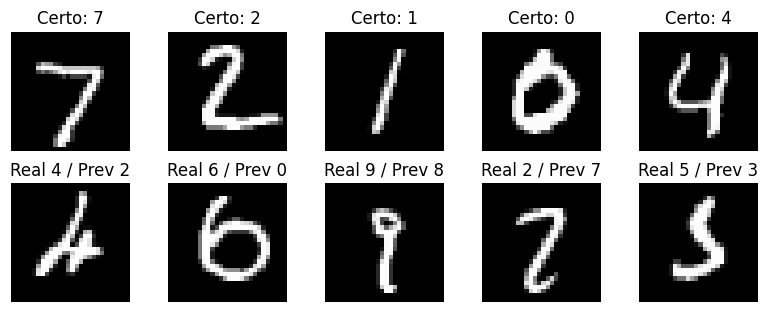

In [12]:
correct_idx = np.where(y_pred == y_test)[0]
wrong_idx = np.where(y_pred != y_test)[0]

fig, axes = plt.subplots(2, 5, figsize=(8, 3.2))
for i, ax in enumerate(axes[0]):
    idx = correct_idx[i]
    ax.imshow(x_test[idx].squeeze(), cmap='gray')
    ax.set_title(f'Certo: {y_pred[idx]}')
    ax.axis('off')

for i, ax in enumerate(axes[1]):
    idx = wrong_idx[i]
    ax.imshow(x_test[idx].squeeze(), cmap='gray')
    ax.set_title(f'Real {y_test[idx]} / Prev {y_pred[idx]}')
    ax.axis('off')

plt.tight_layout()
plt.show()